#  Модуль 6. Работа с выбросами (Outliers)

## Подробный конспект

### 6.1. Зачем изучать выбросы

Представьте, что вы считаете среднюю зарплату в отделе из 10 человек. Девять получают по 60 000 ₽, а десятый — генеральный директор с зарплатой 5 000 000 ₽. Среднее получится 554 000 ₽. Это число «врёт» о реальном положении дел.

**Выброс** — это наблюдение, которое сильно отличается от остальных. Оно может:
- Искажать среднее и стандартное отклонение
- Ухудшать качество моделей (особенно линейных)
- Сигнализировать об ошибке в данных
- **Или** быть самым ценным наблюдением (мошенничество, редкая болезнь, уникальный клиент)

Задача аналитика — не слепо удалить всё, что «не так», а **понять**, что это за выброс и что с ним делать.

### 6.2. Что такое выброс

**Определение:** выброс — точка данных, которая лежит аномально далеко от основной массы распределения.

**Не путать с пропуском:**
- **Пропуск** — данных нет (`NaN`, пустая ячейка)
- **Выброс** — данные есть, но они странные

**Примеры выбросов:**

| Признак | Нормальные значения | Выброс | Почему выброс |
|---------|-------------------|--------|---------------|
| Возраст | 18–70 лет | 250 лет | Физически невозможно |
| Температура тела | 35.5–37.5° | 42.5° | Возможно, но критическая аномалия |
| Цена квартиры | 3–15 млн ₽ | 50 млн ₽ в обычном районе | Статистически далеко от массы |
| Время на сайте | 1–30 минут | 48 часов | Бот или зависшая вкладка |
| Количество транзакций | 0–10 в день | 500 в час | Мошенничество |

#### Причины появления выбросов

1. **Ошибки ввода** — лишний ноль (500000 вместо 50000), опечатка
2. **Ошибки измерения** — сломанный датчик, сбой в системе
3. **Ошибки слияния** — неправильный join таблиц, дублирование с множителем
4. **Естественная вариативность** — в данных действительно есть редкие, но легитимные значения
5. **Фрод / аномальное поведение** — мошеннические транзакции, взлом, поломка оборудования

### 6.3. Статистические методы обнаружения

#### Метод 1: Межквартильный размах (IQR)

Это самый популярный и простой метод. Он основан на квартилах, которые мы изучили в Модуле 2.

**Алгоритм:**
1. Найти Q1 (25-й перцентиль) и Q3 (75-й перцентиль)
2. Вычислить IQR = Q3 − Q1
3. Определить границы:
   - Нижняя: Q1 − 1.5 × IQR
   - Верхняя: Q3 + 1.5 × IQR
4. Всё, что за границами — выброс

**Почему именно 1.5?** Это эмпирическое правило, пришедшее из статистики (связано с нормальным распределением). Можно использовать 3.0 для «экстремальных» выбросов.

In [4]:
import pandas as pd
import numpy as np

# Демо-данные
np.random.seed(42)
data = np.concatenate([
    np.random.normal(50000, 10000, 100),  # нормальные зарплаты
    [200000, 250000, -5000]               # явные выбросы
])
df = pd.DataFrame({'доход': data})

# Расчёт IQR
Q1 = df['доход'].quantile(0.25)
Q3 = df['доход'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.0f}, Q3 = {Q3:.0f}, IQR = {IQR:.0f}")
print(f"Границы: [{lower_bound:.0f}, {upper_bound:.0f}]")

# Поиск выбросов
outliers_iqr = df[(df['доход'] < lower_bound) | (df['доход'] > upper_bound)]
print(f"Найдено выбросов: {len(outliers_iqr)}")
print(outliers_iqr)

# Функция-обёртка
def find_outliers_iqr(series, k=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    return (series < lower) | (series > upper)

df['выброс_iqr'] = find_outliers_iqr(df['доход'])

Q1 = 43988, Q3 = 55050, IQR = 11062
Границы: [27396, 71642]
Найдено выбросов: 4
             доход
74    23802.548959
100  200000.000000
101  250000.000000
102   -5000.000000


**Плюсы:** простой, не требует нормальности, устойчив к выбросам (использует медиану и квартили).
**Минусы:** работает только с одним признаком за раз; при сильно скошенном распределении может быть слишком агрессивным.

#### Метод 2: Z-score (стандартный балл)

Показывает, на сколько стандартных отклонений точка удалена от среднего.

**Формула:**
$$Z = \frac{X - \mu}{\sigma}$$

Где $\mu$ — среднее, $\sigma$ — стандартное отклонение.

**Правило трёх сигм:** для нормального распределения 99.7% данных лежат в интервале [μ − 3σ, μ + 3σ]. Значит, если |Z| > 3 — это потенциальный выброс.

In [10]:
from scipy import stats

# Z-score
df['z_score'] = np.abs(stats.zscore(df['доход']))

# Или через pandas
mean = df['доход'].mean()
std = df['доход'].std()
df['z_score_manual'] = (df['доход'] - mean).abs() / std

print(df)

# Выбросы: |Z| > 3
outliers_z = df[df['z_score'] > 3]
print(f"Выбросов по Z-score: {len(outliers_z)}")
print(outliers_z)

             доход  выброс_iqr   z_score  z_score_manual  modified_z
0     54967.141530       False  0.116515        0.115948    0.780096
1     48617.356988       False  0.121279        0.120689    0.028811
2     56476.885381       False  0.173054        0.172212    0.972424
3     65230.298564       False  0.500862        0.498425    2.087532
4     47658.466253       False  0.157189        0.156424    0.150965
..             ...         ...       ...             ...         ...
98    50051.134566       False  0.067585        0.067257    0.153840
99    47654.128666       False  0.157351        0.156586    0.151518
100  200000.000000        True  5.547879        5.520882   19.256004
101  250000.000000        True  7.420339        7.384230   25.625563
102   -5000.000000        True  2.129206        2.118845    6.859190

[103 rows x 5 columns]
Выбросов по Z-score: 2
        доход  выброс_iqr   z_score  z_score_manual  modified_z
100  200000.0        True  5.547879        5.520882   19.2560

**Проблема Z-score:** среднее и стандартное отклонение сами чувствительны к выбросам. Один огромный выброс «растянет» σ, и другие выбросы могут остаться незамеченными.

**Когда использовать:** данные примерно нормально распределены, выбросов немного.

#### Метод 3: Модифицированный Z-score (MAD-based)

Решает проблему обычного Z-score, заменяя среднее и стандартное отклонение на **медиану** и **MAD** (Median Absolute Deviation — медианное абсолютное отклонение).

**Формула:**
$$M_i = \frac{0.6745 \times (X_i - \text{медиана})}{\text{MAD}}$$

Где $\text{MAD} = \text{медиана}(|X_i - \text{медиана}|)$

Коэффициент 0.6745 подбирается так, чтобы MAD совпадал со стандартным отклонением для нормального распределения.

**Порог:** если $|M_i| > 3.5$ — выброс.

In [11]:
def modified_z_score(series):
    median = series.median()
    mad = np.median(np.abs(series - median))
    modified_z = 0.6745 * (series - median) / mad
    return np.abs(modified_z)

df['modified_z'] = modified_z_score(df['доход'])
outliers_mad = df[df['modified_z'] > 3.5]
print(f"Выбросов по модифицированному Z-score: {len(outliers_mad)}")
print(outliers_mad)

Выбросов по модифицированному Z-score: 3
        доход  выброс_iqr   z_score  z_score_manual  modified_z
100  200000.0        True  5.547879        5.520882   19.256004
101  250000.0        True  7.420339        7.384230   25.625563
102   -5000.0        True  2.129206        2.118845    6.859190


**Плюсы:** устойчив к выбросам, хорош для ненормальных распределений.
**Минусы:** если MAD = 0 (много одинаковых значений), формула ломается.

### 6.4. Методы на основе расстояний и ML

Когда данных много и признаков много, статистические методы не справляются. Нужны алгоритмы, которые учитывают **многомерное пространство**.

#### Isolation Forest (Изолирующий лес)

**Идея:** выбросы — это редкие и «непохожие» точки. Их легче «изолировать» от остальных данных, чем нормальные точки.

**Как работает (упрощённо):**
1. Алгоритм строит много случайных деревьев решений
2. На каждом шаге случайно выбирает признак и случайное значение для разбиения
3. Считает, за сколько шагов точка «отделилась» от всех остальных
4. Выбросы изолируются быстрее (меньше шагов) — они сразу попадают в отдельную ветку

In [18]:
from sklearn.ensemble import IsolationForest

# Подготовим многомерные данные
rng = np.random.default_rng(seed=42)
df_multi = pd.DataFrame({
    'возраст': rng.normal(35, 10, 1000).clip(18, 70),
    'доход': rng.lognormal(11, 0.5, 1000),
    'стаж': rng.poisson(8, 1000)
})

# Добавим выбросы
outliers_data = pd.DataFrame({
    'возраст': [15, 85, 90],
    'доход': [5000000, 10000, 8000000],
    'стаж': [0, 50, 60]
})
df_multi = pd.concat([df_multi, outliers_data], ignore_index=True)
df_multi

,возраст,доход,стаж
0,38.047171,5.812544e+04,6
1,24.600159,4.157925e+04,7
2,42.504512,4.866734e+04,9
3,44.405647,8.220367e+04,9
4,18.000000,5.996382e+04,7
...,...,...,...
998,36.307642,4.591693e+04,12
999,43.237531,1.811492e+05,17
1000,15.000000,5.000000e+06,0
1001,85.000000,1.000000e+04,50


**Параметры `IsolationForest`:**
- `contamination` — доля выбросов в данных. Если не знаете — начните с 0.01–0.05.
- `n_estimators` — количество деревьев (обычно 100 достаточно).

In [19]:
# Isolation Forest
# contamination — ожидаемая доля выбросов (примерно)
iso_forest = IsolationForest(contamination=0.01, random_state=42)
df_multi['выброс_iso'] = iso_forest.fit_predict(df_multi)
df_multi

,возраст,доход,стаж,выброс_iso
0,38.047171,5.812544e+04,6,1
1,24.600159,4.157925e+04,7,1
2,42.504512,4.866734e+04,9,1
3,44.405647,8.220367e+04,9,1
4,18.000000,5.996382e+04,7,1
...,...,...,...,...
998,36.307642,4.591693e+04,12,1
999,43.237531,1.811492e+05,17,-1
1000,15.000000,5.000000e+06,0,-1
1001,85.000000,1.000000e+04,50,-1


In [20]:
# -1 = выброс, 1 = норма
outliers_iso = df_multi[df_multi['выброс_iso'] == -1]
print(f"Найдено выбросов: {len(outliers_iso)}")
outliers_iso

Найдено выбросов: 11


,возраст,доход,стаж,выброс_iso
166,44.315730,2.045795e+05,17,-1
338,46.553120,2.322043e+05,11,-1
456,45.762402,1.890552e+05,2,-1
479,60.976737,1.404949e+05,8,-1
616,42.138201,2.570748e+05,9,-1
660,18.080374,1.974965e+05,8,-1
769,51.818166,2.439661e+05,8,-1
999,43.237531,1.811492e+05,17,-1
1000,15.000000,5.000000e+06,0,-1
1001,85.000000,1.000000e+04,50,-1


In [21]:
# Оценка аномальности (чем меньше, тем «страннее» точка)
df_multi['anomaly_score'] = iso_forest.score_samples(df_multi[['возраст', 'доход', 'стаж']])
df_multi

,возраст,доход,стаж,выброс_iso,anomaly_score
0,38.047171,5.812544e+04,6,1,-0.382167
1,24.600159,4.157925e+04,7,1,-0.420223
2,42.504512,4.866734e+04,9,1,-0.406921
3,44.405647,8.220367e+04,9,1,-0.427008
4,18.000000,5.996382e+04,7,1,-0.459794
...,...,...,...,...,...
998,36.307642,4.591693e+04,12,1,-0.435715
999,43.237531,1.811492e+05,17,-1,-0.680616
1000,15.000000,5.000000e+06,0,-1,-0.749753
1001,85.000000,1.000000e+04,50,-1,-0.770346


**Плюсы:** работает с многими признаками, быстрый, не требует нормальности.
**Минусы:** случайный алгоритм — результаты могут немного меняться; плохо находит локальные выбросы (см. LOF).

#### Local Outlier Factor (LOF)

**Идея:** выброс — это точка, у которой **локальная плотность** сильно ниже, чем у её соседей.

**Пример:** в деревне средняя зарплата 20 000 ₽. Человек с зарплатой 100 000 ₽ — выброс. Но в Москве зарплата 100 000 ₽ — норма. LOF понимает контекст: он сравнивает точку с её ближайшими соседями, а не со всем датасетом.

In [22]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
df_multi['выброс_lof'] = lof.fit_predict(df_multi[['возраст', 'доход', 'стаж']])
df_multi

,возраст,доход,стаж,выброс_iso,anomaly_score,выброс_lof
0,38.047171,5.812544e+04,6,1,-0.382167,1
1,24.600159,4.157925e+04,7,1,-0.420223,1
2,42.504512,4.866734e+04,9,1,-0.406921,1
3,44.405647,8.220367e+04,9,1,-0.427008,1
4,18.000000,5.996382e+04,7,1,-0.459794,1
...,...,...,...,...,...,...
998,36.307642,4.591693e+04,12,1,-0.435715,1
999,43.237531,1.811492e+05,17,-1,-0.680616,1
1000,15.000000,5.000000e+06,0,-1,-0.749753,-1
1001,85.000000,1.000000e+04,50,-1,-0.770346,-1


In [23]:
# -1 = выброс, 1 = норма
outliers_lof = df_multi[df_multi['выброс_lof'] == -1]
print(f"Найдено выбросов LOF: {len(outliers_lof)}")
outliers_lof

Найдено выбросов LOF: 11


,возраст,доход,стаж,выброс_iso,anomaly_score,выброс_lof
77,36.585397,2.439224e+05,6,1,-0.625732,-1
338,46.553120,2.322043e+05,11,-1,-0.649495,-1
381,48.095507,1.427796e+04,7,1,-0.509353,-1
437,24.302476,1.365950e+04,7,1,-0.496743,-1
616,42.138201,2.570748e+05,9,-1,-0.644750,-1
769,51.818166,2.439661e+05,8,-1,-0.674720,-1
913,28.778323,1.392471e+04,5,1,-0.507948,-1
915,46.575078,1.304531e+04,9,1,-0.508146,-1
1000,15.000000,5.000000e+06,0,-1,-0.749753,-1
1001,85.000000,1.000000e+04,50,-1,-0.770346,-1


In [24]:
# Отрицательный LOF score (чем меньше, тем аномальнее)
df_multi['lof_score'] = lof.negative_outlier_factor_
df_multi

,возраст,доход,стаж,выброс_iso,anomaly_score,выброс_lof,lof_score
0,38.047171,5.812544e+04,6,1,-0.382167,1,-1.097087
1,24.600159,4.157925e+04,7,1,-0.420223,1,-1.008254
2,42.504512,4.866734e+04,9,1,-0.406921,1,-1.071471
3,44.405647,8.220367e+04,9,1,-0.427008,1,-1.004180
4,18.000000,5.996382e+04,7,1,-0.459794,1,-0.970039
...,...,...,...,...,...,...,...
998,36.307642,4.591693e+04,12,1,-0.435715,1,-1.031366
999,43.237531,1.811492e+05,17,-1,-0.680616,1,-1.246970
1000,15.000000,5.000000e+06,0,-1,-0.749753,-1,-144.036136
1001,85.000000,1.000000e+04,50,-1,-0.770346,-1,-2.813011


**Когда LOF лучше Isolation Forest:**
- Данные имеют **разную плотность** в разных областях (кластеры разного размера)
- Нужно находить **локальные** выбросы (точки, странные только в своём окружении)

**Минусы:** медленнее на больших данных (нужно считать расстояния до соседей).

### 6.5. Кластеризация: DBSCAN

DBSCAN (Density-Based Spatial Clustering) группирует точки в кластеры по плотности. Точки, которые не попали ни в один кластер, помечаются как **шум** (noise) — это и есть выбросы.

**Идея:**
- **Core point** (ядро): точка, вокруг которой в радиусе ε есть минимум N точек
- **Border point** (граница): точка в радиусе ε от ядра, но сама не является ядром
- **Noise** (шум): всё остальное — выбросы

In [27]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Масштабируем данные (DBSCAN чувствителен к масштабам!)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_multi[['возраст', 'доход', 'стаж']])

**Параметры:**
- `eps` (ε) — радиус окрестности. Слишком маленький — всё станет шумом. Слишком большой — выбросы попадут в кластер.
- `min_samples` — минимальное число точек для ядра.

In [28]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df_multi['кластер_dbscan'] = dbscan.fit_predict(df_scaled)
df_multi

,возраст,доход,стаж,выброс_iso,anomaly_score,выброс_lof,lof_score,кластер_dbscan
0,38.047171,5.812544e+04,6,1,-0.382167,1,-1.097087,0
1,24.600159,4.157925e+04,7,1,-0.420223,1,-1.008254,0
2,42.504512,4.866734e+04,9,1,-0.406921,1,-1.071471,0
3,44.405647,8.220367e+04,9,1,-0.427008,1,-1.004180,0
4,18.000000,5.996382e+04,7,1,-0.459794,1,-0.970039,0
...,...,...,...,...,...,...,...,...
998,36.307642,4.591693e+04,12,1,-0.435715,1,-1.031366,0
999,43.237531,1.811492e+05,17,-1,-0.680616,1,-1.246970,0
1000,15.000000,5.000000e+06,0,-1,-0.749753,-1,-144.036136,-1
1001,85.000000,1.000000e+04,50,-1,-0.770346,-1,-2.813011,-1


In [29]:
# -1 = шум (выброс)
outliers_dbscan = df_multi[df_multi['кластер_dbscan'] == -1]
print(f"Выбросов DBSCAN: {len(outliers_dbscan)}")
outliers_dbscan

Выбросов DBSCAN: 13


,возраст,доход,стаж,выброс_iso,anomaly_score,выброс_lof,lof_score,кластер_dbscan
139,64.138625,5.998790e+04,11,1,-0.610223,1,-0.971914,-1
189,51.509279,5.579871e+04,23,1,-0.626513,1,-1.010655,-1
226,60.174740,8.619411e+04,12,1,-0.615886,1,-1.054766,-1
248,64.050672,5.495213e+04,7,1,-0.597675,1,-1.014510,-1
456,45.762402,1.890552e+05,2,-1,-0.659963,1,-1.357768,-1
515,38.446452,6.651253e+04,18,1,-0.573388,1,-1.018019,-1
553,55.350733,4.987450e+04,17,1,-0.632020,1,-1.014399,-1
722,18.000000,4.298684e+04,16,1,-0.586987,1,-0.981273,-1
835,26.056540,6.256626e+04,17,1,-0.569573,1,-0.970919,-1
846,66.788537,6.086099e+04,7,1,-0.607974,1,-1.001576,-1


**Плюсы:** не нужно задавать число кластеров, находит произвольные формы.
**Минусы:** сложно подобрать `eps`, чувствителен к масштабу признаков.

### 6.6. Визуализация выбросов

#### Boxplot — классика

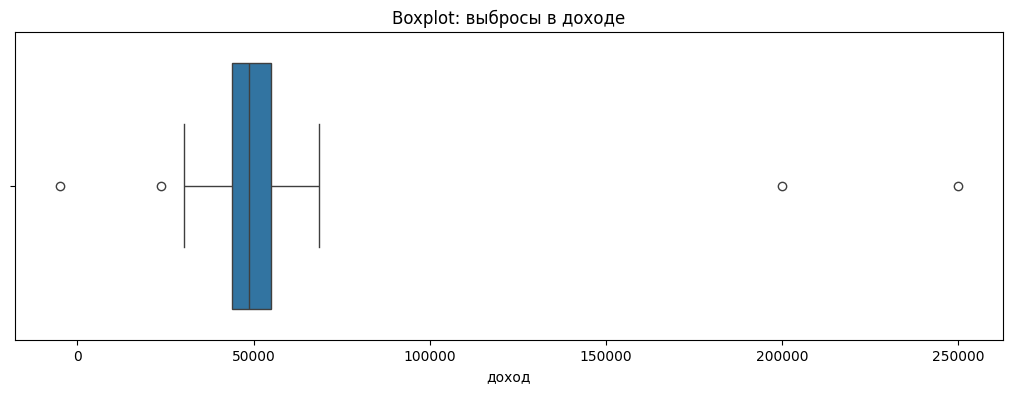

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12.75, 4))
sns.boxplot(x=df['доход'])
plt.title('Boxplot: выбросы в доходе')
plt.show()

Точки за усами — потенциальные выбросы (по правилу IQR 1.5).

#### Scatterplot для двух признаков

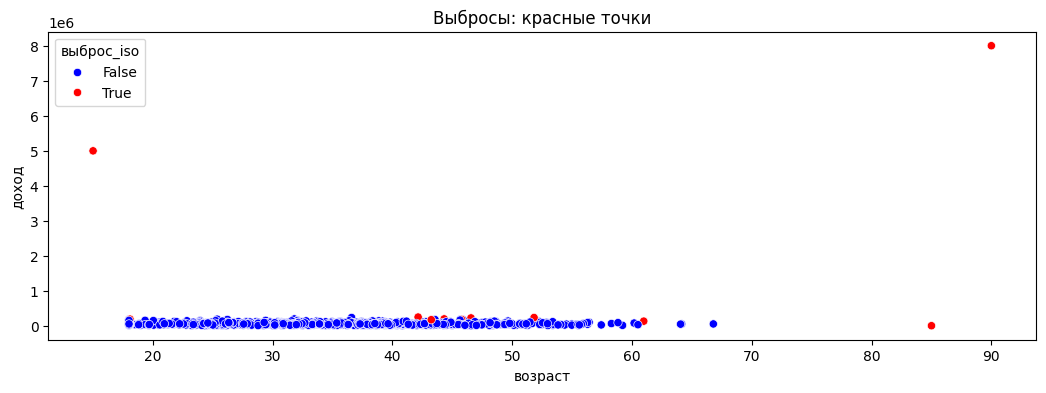

In [41]:
plt.figure(figsize=(12.75, 4))
sns.scatterplot(data=df_multi, x='возраст', y='доход', 
                hue=(df_multi['выброс_iso'] == -1), palette={True: 'red', False: 'blue'})
plt.title('Выбросы: красные точки')
plt.show()

### 6.7. Стратегии работы с выбросами

Найти выброс — это только полдела. Главный вопрос: **что с ним делать?**

#### Стратегия 1: Удаление

Самый радикальный способ. Удаляем строки с выбросами.

In [ ]:
# Удаляем выбросы, найденные IQR
df_clean = df[~find_outliers_iqr(df['доход'])].copy()

# Или по Isolation Forest
df_clean = df_multi[df_multi['выброс_iso'] == 1].copy()

**Когда удалять:**
- Выброс — явная ошибка (возраст 250 лет, отрицательная цена)
- Выбросов немного (< 1–2%)
- Выброс не несёт полезной информации

**Когда НЕ удалять:**
- Выброс — редкое, но реальное событие (миллионер в выборке зарплат)
- Выброс — это то, что вы ищете (мошенничество, поломка)
- Выбросов много (> 5–10%) — удаление исказит распределение

#### Стратегия 2: Ограничение (Capping / Winsorization / Flooring)

Вместо удаления «обрезаем» значения по границам.

In [43]:
# Вручную: заменить всё, что выше 99-го перцентиля, на 99-й перцентиль
upper_limit = df['доход'].quantile(0.99)
lower_limit = df['доход'].quantile(0.01)

df['доход_capped'] = df['доход'].clip(lower=lower_limit, upper=upper_limit)

# Или через scipy (Winsorization)
from scipy.stats.mstats import winsorize

df['доход_winsorized'] = winsorize(df['доход'], limits=[0.01, 0.01]) #урезаем по 1% с каждого хвоста распределения
df

,доход,выброс_iqr,z_score,z_score_manual,modified_z,доход_capped,доход_winsorized
0,54967.141530,False,0.116515,0.115948,0.780096,54967.141530,54967.141530
1,48617.356988,False,0.121279,0.120689,0.028811,48617.356988,48617.356988
2,56476.885381,False,0.173054,0.172212,0.972424,56476.885381,56476.885381
3,65230.298564,False,0.500862,0.498425,2.087532,65230.298564,65230.298564
4,47658.466253,False,0.157189,0.156424,0.150965,47658.466253,47658.466253
...,...,...,...,...,...,...,...
98,50051.134566,False,0.067585,0.067257,0.153840,50051.134566,50051.134566
99,47654.128666,False,0.157351,0.156586,0.151518,47654.128666,47654.128666
100,200000.000000,True,5.547879,5.520882,19.256004,197370.455637,200000.000000
101,250000.000000,True,7.420339,7.384230,25.625563,197370.455637,200000.000000


**Плюсы:** сохраняем все строки, не теряем данные.  
**Минусы:** искажаем реальные значения; несколько разных выбросов станут одинаковыми.

#### Стратегия 3: Трансформация

Если выбросы возникают из-за скошенного распределения, можно «сжать» хвост.

In [45]:
# Логарифмическое преобразование (для правосторонней асимметрии)
df['доход_log'] = np.log1p(df['доход'])  # log1p = log(1 + x), безопасно для 0

# Квадратный корень (более мягкое сжатие)
df['доход_sqrt'] = np.sqrt(df['доход'].clip(lower=0))

# Box-Cox (автоматический подбор степени)
from scipy.stats import boxcox
df['доход_boxcox'], lambda_param = boxcox(df['доход'].clip(lower=1))
df

,доход,выброс_iqr,z_score,z_score_manual,modified_z,доход_capped,доход_winsorized,доход_log,доход_sqrt,доход_boxcox
0,54967.141530,False,0.116515,0.115948,0.780096,54967.141530,54967.141530,10.914509,234.450723,327.924188
1,48617.356988,False,0.121279,0.120689,0.028811,48617.356988,48617.356988,10.791756,220.493440,309.791407
2,56476.885381,False,0.173054,0.172212,0.972424,56476.885381,56476.885381,10.941604,237.648660,332.066567
3,65230.298564,False,0.500862,0.498425,2.087532,65230.298564,65230.298564,11.085695,255.402229,354.984436
4,47658.466253,False,0.157189,0.156424,0.150965,47658.466253,47658.466253,10.771837,218.308191,306.944285
...,...,...,...,...,...,...,...,...,...,...
98,50051.134566,False,0.067585,0.067257,0.153840,50051.134566,50051.134566,10.820820,223.721109,313.992585
99,47654.128666,False,0.157351,0.156586,0.151518,47654.128666,47654.128666,10.771746,218.298256,306.931336
100,200000.000000,True,5.547879,5.520882,19.256004,197370.455637,200000.000000,12.206078,447.213595,595.975002
101,250000.000000,True,7.420339,7.384230,25.625563,197370.455637,200000.000000,12.429220,500.000000,660.671324


После трансформации выбросы «приближаются» к основной массе, и модель меньше на них реагирует.

#### Стратегия 4: Создание признака-индикатора

Сохраняем исходное значение, но добавляем флаг: «это был выброс».

In [46]:
# Находим выбросы
is_outlier = find_outliers_iqr(df['доход'])

# Создаём признак-индикатор
df['доход_выброс'] = is_outlier.astype(int)

# Ограничиваем оригинальный столбец (или оставляем как есть)
df['доход_ограниченный'] = df['доход'].clip(
    lower=df['доход'].quantile(0.05),
    upper=df['доход'].quantile(0.95)
)
df

,доход,выброс_iqr,z_score,z_score_manual,modified_z,доход_capped,доход_winsorized,доход_log,доход_sqrt,доход_boxcox,доход_выброс,доход_ограниченный
0,54967.141530,False,0.116515,0.115948,0.780096,54967.141530,54967.141530,10.914509,234.450723,327.924188,0,54967.141530
1,48617.356988,False,0.121279,0.120689,0.028811,48617.356988,48617.356988,10.791756,220.493440,309.791407,0,48617.356988
2,56476.885381,False,0.173054,0.172212,0.972424,56476.885381,56476.885381,10.941604,237.648660,332.066567,0,56476.885381
3,65230.298564,False,0.500862,0.498425,2.087532,65230.298564,65230.298564,11.085695,255.402229,354.984436,0,65230.298564
4,47658.466253,False,0.157189,0.156424,0.150965,47658.466253,47658.466253,10.771837,218.308191,306.944285,0,47658.466253
...,...,...,...,...,...,...,...,...,...,...,...,...
98,50051.134566,False,0.067585,0.067257,0.153840,50051.134566,50051.134566,10.820820,223.721109,313.992585,0,50051.134566
99,47654.128666,False,0.157351,0.156586,0.151518,47654.128666,47654.128666,10.771746,218.298256,306.931336,0,47654.128666
100,200000.000000,True,5.547879,5.520882,19.256004,197370.455637,200000.000000,12.206078,447.213595,595.975002,1,65365.358955
101,250000.000000,True,7.420339,7.384230,25.625563,197370.455637,200000.000000,12.429220,500.000000,660.671324,1,65365.358955


**Зачем:** модель получает два сигнала:
1. Числовое значение (в пределах нормы)
2. Флаг «это была аномалия»

Это особенно полезно, если выбросы — это важные события (мошенники, VIP-клиенты).

### 6.8. Когда выброс — не выброс

Это самый важный раздел. Не все «странные» точки нужно удалять.

#### Случай 1: Фрод (мошенничество)

В антифрод-системах выбросы — это **целевые события**. 500 транзакций за минуту — это не ошибка, это атака.

**Что делать:** не удалять, а изучать. Создавать признаки на основе аномального поведения.

#### Случай 2: Редкие события

В медицине: редкая болезнь проявляется экстремальными значениями анализов. Удалив выброс, вы потеряете пациента.

#### Случай 3: Экспоненциальное / логнормальное распределение

Если данные естественно скошены (доходы, цены на жильё), то «выбросы» на самом деле — нормальная часть распределения. Удалять их — значит искажать реальность.

**Проверка:** постройте гистограмму. Если это логнормальное распределение — лучше трансформировать, чем удалять.

#### Случай 4: Разные подгруппы

В данных могут быть скрытые кластеры. Например, в выборке зарплат смешаны junior и senior разработчики. Зарплата senior — не выброс, а другая подгруппа.

**Решение:** добавить признак «уровень» или сегментировать данные.

### 6.9. Практический пример: полный цикл работы с выбросами

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from scipy import stats

rng = np.random.default_rng(seed=42)

# Создаём данные с выбросами
n = 1000
df = pd.DataFrame({
    'возраст': np.concatenate([
        rng.normal(35, 10, n).clip(18, 70).astype(int),
        [5, 95, 120]  # выбросы
    ]),
    'доход': np.concatenate([
        rng.lognormal(11, 0.5, n),
        [5000000, 8000000, -100000]  # выбросы
    ]),
    'стаж': np.concatenate([
        rng.poisson(8, n),
        [60, -5, 80]  # выбросы
    ])
})

print(f"Размер датасета: {df.shape}")
print("\nСтатистика ДО обработки:")
print(df.describe())
df

Размер датасета: (1003, 3)

Статистика ДО обработки:
           возраст         доход         стаж
count  1003.000000  1.003000e+03  1003.000000
mean     34.555334  7.795975e+04     8.027916
std      10.021518  2.969949e+05     4.039379
min       5.000000 -1.000000e+05    -5.000000
25%      28.000000  4.154509e+04     6.000000
50%      35.000000  5.859667e+04     8.000000
75%      40.500000  8.100834e+04    10.000000
max     120.000000  8.000000e+06    80.000000


,возраст,доход,стаж
0,38,5.812544e+04,6
1,24,4.157925e+04,7
2,42,4.866734e+04,9
3,44,8.220367e+04,9
4,18,5.996382e+04,7
...,...,...,...
998,36,4.591693e+04,12
999,43,1.811492e+05,17
1000,5,5.000000e+06,60
1001,95,8.000000e+06,-5


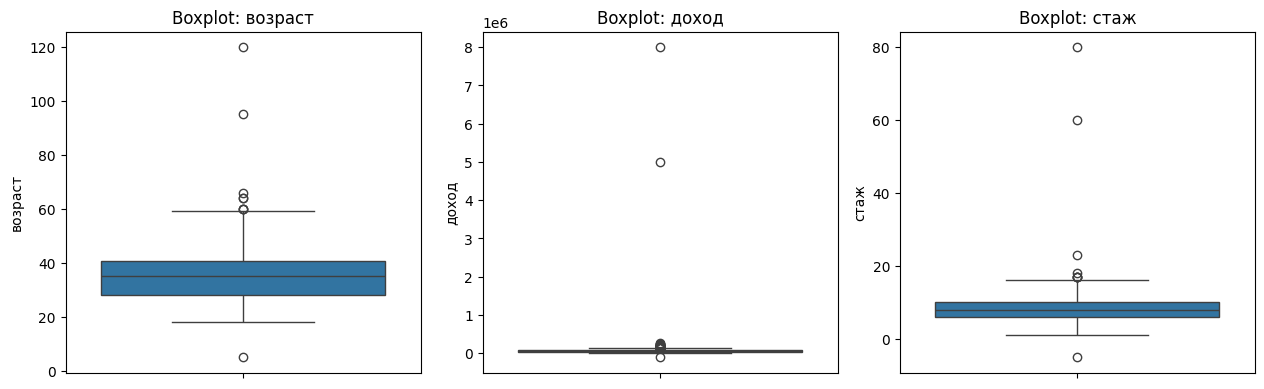

In [52]:
# === ШАГ 1: ВИЗУАЛИЗАЦИЯ ===
fig, axes = plt.subplots(1, 3, figsize=(12.75, 4))
for idx, col in enumerate(['возраст', 'доход', 'стаж']):
    sns.boxplot(y=df[col], ax=axes[idx])
    axes[idx].set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

In [53]:
# === ШАГ 2: IQR ===
def detect_outliers_iqr(data, column, k=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    return (data[column] < lower) | (data[column] > upper)

for col in ['возраст', 'доход', 'стаж']:
    df[f'{col}_outlier_iqr'] = detect_outliers_iqr(df, col)

# === ШАГ 3: Z-SCORE ===
for col in ['возраст', 'доход', 'стаж']:
    df[f'{col}_zscore'] = np.abs(stats.zscore(df[col]))
    df[f'{col}_outlier_z'] = df[f'{col}_zscore'] > 3

# === ШАГ 4: ISOLATION FOREST (многомерный) ===
iso = IsolationForest(contamination=0.01, random_state=42)
df['outlier_iso'] = iso.fit_predict(df[['возраст', 'доход', 'стаж']])
df['outlier_iso'] = (df['outlier_iso'] == -1).astype(int)
df

,возраст,доход,стаж,возраст_outlier_iqr,доход_outlier_iqr,стаж_outlier_iqr,возраст_zscore,возраст_outlier_z,доход_zscore,доход_outlier_z,стаж_zscore,стаж_outlier_z,outlier_iso
0,38,5.812544e+04,6,False,False,False,0.343898,False,0.066817,False,0.502287,False,0
1,24,4.157925e+04,7,False,False,False,1.053792,False,0.122556,False,0.254601,False,0
2,42,4.866734e+04,9,False,False,False,0.743239,False,0.098679,False,0.240772,False,0
3,44,8.220367e+04,9,False,False,False,0.942909,False,0.014297,False,0.240772,False,0
4,18,5.996382e+04,7,False,False,False,1.652803,False,0.060624,False,0.254601,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
998,36,4.591693e+04,12,False,False,False,0.144228,False,0.107944,False,0.983831,False,0
999,43,1.811492e+05,17,False,True,True,0.843074,False,0.347619,False,2.222262,False,1
1000,5,5.000000e+06,60,True,True,True,2.950659,False,16.581079,True,12.872773,True,1
1001,95,8.000000e+06,-5,True,True,True,6.034497,True,26.687303,True,3.226836,True,1


In [54]:
# === ШАГ 5: СТРАТЕГИЯ ОБРАБОТКИ ===
# Для возраста: ограничение (реальный возраст не может быть < 18 и > 100)
df['возраст_clean'] = df['возраст'].clip(18, 100)

# Для дохода: логарифм + индикатор выброса
df['доход_log'] = np.log1p(df['доход'].clip(lower=0))
df['доход_выброс'] = df['доход_outlier_iqr'].astype(int)

# Для стажа: ограничение + индикатор
df['стаж_clean'] = df['стаж'].clip(0, 50)
df['стаж_выброс'] = df['стаж_outlier_iqr'].astype(int)

print("\nСтатистика ПОСЛЕ обработки:")
print(df[['возраст_clean', 'доход_log', 'стаж_clean']].describe())

print(f"\nВыбросов IQR: {df[['возраст_outlier_iqr', 'доход_outlier_iqr', 'стаж_outlier_iqr']].sum().sum()}")
print(f"Выбросов Isolation Forest: {df['outlier_iso'].sum()}")


Статистика ПОСЛЕ обработки:
       возраст_clean    доход_log   стаж_clean
count    1003.000000  1003.000000  1003.000000
mean       34.548355    10.957777     7.993021
std         9.839754     0.648553     3.444013
min        18.000000     0.000000     0.000000
25%        28.000000    10.634558     6.000000
50%        35.000000    10.978450     8.000000
75%        40.500000    11.302319    10.000000
max       100.000000    15.894952    50.000000

Выбросов IQR: 60
Выбросов Isolation Forest: 11


### 6.10. Чек-лист для самопроверки

Перед переходом к Модулю 7 убедитесь, что вы:

- [ ] Можете отличить выброс от пропуска
- [ ] Знаете три основные причины появления выбросов (ошибки, вариативность, фрод)
- [ ] Умеете находить выбросы методом IQR с формулой Q1 − 1.5×IQR и Q3 + 1.5×IQR
- [ ] Можете рассчитать Z-score и применить правило трёх сигм
- [ ] Понимаете, почему обычный Z-score чувствителен к выбросам
- [ ] Знаете, что такое модифицированный Z-score и MAD
- [ ] Понимаете принцип работы Isolation Forest
- [ ] Знаете разницу между Isolation Forest и LOF
- [ ] Понимаете, как DBSCAN находит выбросы как шум
- [ ] Умеете визуализировать выбросы через boxplot и scatterplot
- [ ] Можете применить стратегии: удаление, ограничение (capping), трансформацию, индикатор
- [ ] Понимаете, когда выброс удалять нельзя (фрод, редкие события, подгруппы)
- [ ] Знаете, что логнормальное распределение естественно даёт «тяжёлый хвост»

> **Переход к Модулю 7:** Теперь, когда вы умеете находить и обрабатывать аномалии, пора научиться преобразовывать сами распределения признаков. Мы изучим методы, которые делают данные более «удобными» для моделей: логарифмирование, степенные преобразования и биннинг.